In [1]:
import sys
import os
# Add the project root directory to Python path
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(project_root)

from scripts.utils import get_time_series, get_timestamp_index, plot_weather_data, generate_delay_hours

In [22]:
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
import logging
from datetime import datetime
random.seed(42)         # Python built-in random module
np.random.seed(42)

In [3]:
# 로깅 설정
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler(f"regression_log_{datetime.now().strftime('%Y%m%d_%H%M%S')}.log"),
        logging.StreamHandler()  # 콘솔에도 출력
    ]
)
logger = logging.getLogger(__name__)

# 데이터 로드
logger.info("데이터 로드 시작")

2025-04-08 13:54:21,749 - INFO - 데이터 로드 시작


In [4]:
raw_data = pd.read_csv('../raw_data_20250403.csv')

In [5]:
data = get_timestamp_index(raw_data)

In [6]:
data_seoul_pivot = data[data['city']=='Icheon'].copy()
data_seoul_common = data[data['city']=='Icheon'].copy()

In [7]:
data_seoul_common  = data_seoul_common.groupby('timestamp').first()
data_seoul_common = data_seoul_common[[ 'base_date', 'year', 'month', 'day', 'day_of_week', 'is_holiday', 'base_time', 'hour', 'nx', 'ny', 'admin_district_code','city', 'sub_address']]

In [8]:
data_seoul_pivot['timestamp'] = data_seoul_pivot.index
data_seoul_pivot = data_seoul_pivot.pivot(index='timestamp', columns='category_code', values='measurement_value')

In [9]:
data_seoul_pivot['delay_hours'] = data_seoul_pivot.apply(generate_delay_hours, axis=1)

In [10]:
data_seoul_merged = pd.merge(data_seoul_pivot, data_seoul_common, left_index=True, right_index=True, how='left')

In [11]:
data_seoul_merged

,PTY,REH,RN1,T1H,UUU,VEC,VVV,WSD,delay_hours,base_date,...,day,day_of_week,is_holiday,base_time,hour,nx,ny,admin_district_code,city,sub_address
timestamp,,,,,,,,,,,,,,,,,,,,,
2025-03-19 04:00:00,0.0,75.0,0.0,-2.9,-0.4,140.0,0.6,0.8,0.449816,2025-03-19,...,19,Wednesday,False,0400,4,66,120,4150034000,Icheon,Majang-myeon
2025-03-19 05:00:00,0.0,77.0,0.0,-3.7,-0.2,72.0,0.0,0.3,0.680286,2025-03-19,...,19,Wednesday,False,0500,5,66,120,4150034000,Icheon,Majang-myeon
2025-03-19 06:00:00,0.0,76.0,0.0,-3.7,-0.4,135.0,0.5,0.7,0.592798,2025-03-19,...,19,Wednesday,False,0600,6,66,120,4150034000,Icheon,Majang-myeon
2025-03-19 07:00:00,0.0,79.0,0.0,-4.2,-0.3,117.0,0.2,0.4,0.539463,2025-03-19,...,19,Wednesday,False,0700,7,66,120,4150034000,Icheon,Majang-myeon
2025-03-19 08:00:00,0.0,68.0,0.0,-1.7,-0.1,146.0,0.3,0.4,0.362407,2025-03-19,...,19,Wednesday,False,0800,8,66,120,4150034000,Icheon,Majang-myeon
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-04-03 15:00:00,0.0,25.0,0.0,16.0,1.2,310.0,-0.9,1.6,0.000000,2025-04-03,...,3,Thursday,False,1500,15,66,120,4150034000,Icheon,Majang-myeon
2025-04-03 16:00:00,0.0,23.0,0.0,15.4,0.9,323.0,-1.1,1.5,0.000000,2025-04-03,...,3,Thursday,False,1600,16,66,120,4150034000,Icheon,Majang-myeon
2025-04-03 17:00:00,0.0,38.0,0.0,15.3,2.3,280.0,-0.3,2.3,0.000000,2025-04-03,...,3,Thursday,False,1700,17,66,120,4150034000,Icheon,Majang-myeon


In [12]:
data_seoul_merged.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 375 entries, 2025-03-19 04:00:00 to 2025-04-03 19:00:00
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   PTY                  375 non-null    float64
 1   REH                  375 non-null    float64
 2   RN1                  375 non-null    float64
 3   T1H                  375 non-null    float64
 4   UUU                  375 non-null    float64
 5   VEC                  375 non-null    float64
 6   VVV                  375 non-null    float64
 7   WSD                  375 non-null    float64
 8   delay_hours          375 non-null    float64
 9   base_date            375 non-null    object 
 10  year                 375 non-null    int64  
 11  month                375 non-null    int64  
 12  day                  375 non-null    int64  
 13  day_of_week          375 non-null    object 
 14  is_holiday           375 non-null    bool   
 15  bas

In [13]:
data_seoul_merged.describe()

,PTY,REH,RN1,T1H,UUU,VEC,VVV,WSD,delay_hours,year,month,day,hour,nx,ny,admin_district_code
count,375.000000,375.000000,375.000000,375.000000,375.000000,375.000000,375.000000,375.000000,375.000000,375.0,375.000000,375.000000,375.000000,375.0,375.0,3.750000e+02
mean,0.021333,53.621333,0.004000,9.036267,0.885333,200.133333,0.390933,1.793067,0.083168,2025.0,3.181333,20.888000,11.477333,66.0,120.0,4.150034e+09
std,0.218339,21.199601,0.057673,6.457236,1.511851,85.693917,1.225366,1.265378,0.147712,0.0,0.385809,9.545738,6.843858,0.0,0.0,0.000000e+00
min,0.000000,11.000000,0.000000,-4.200000,-1.600000,7.000000,-3.700000,0.300000,0.000000,2025.0,3.000000,1.000000,0.000000,66.0,120.0,4.150034e+09
25%,0.000000,37.000000,0.000000,4.200000,-0.400000,135.000000,-0.300000,0.800000,0.000000,2025.0,3.000000,20.000000,6.000000,66.0,120.0,4.150034e+09
50%,0.000000,52.000000,0.000000,8.400000,0.400000,210.000000,0.500000,1.400000,0.009903,2025.0,3.000000,24.000000,11.000000,66.0,120.0,4.150034e+09
75%,0.000000,71.500000,0.000000,13.800000,1.900000,268.500000,1.100000,2.600000,0.118196,2025.0,3.000000,28.000000,17.000000,66.0,120.0,4.150034e+09
max,3.000000,96.000000,1.000000,25.000000,7.800000,360.000000,3.700000,8.500000,0.891204,2025.0,4.000000,31.000000,23.000000,66.0,120.0,4.150034e+09


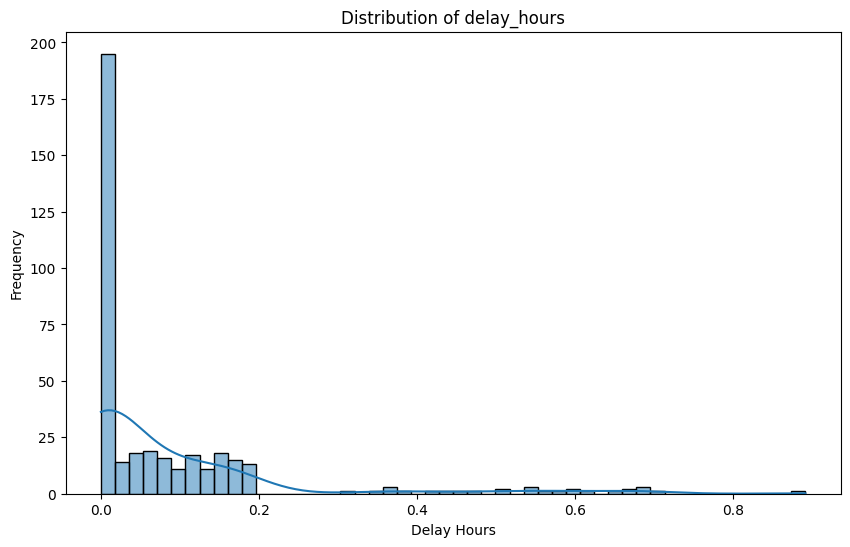

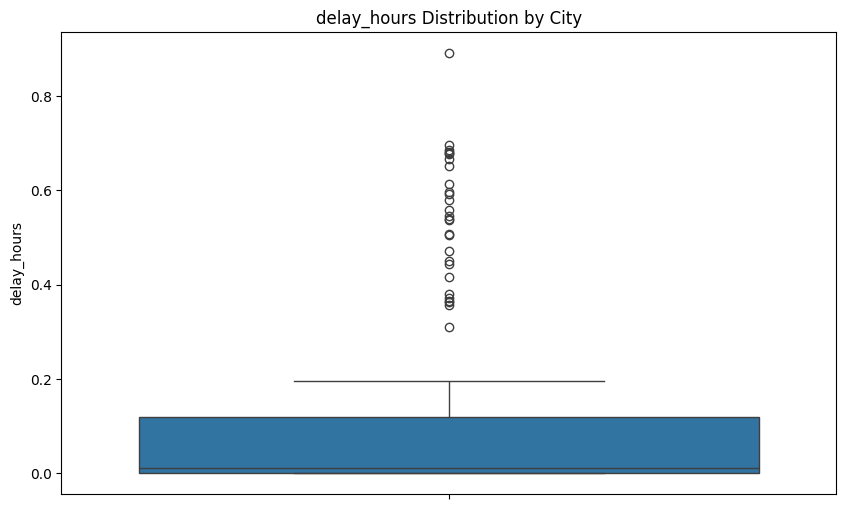

In [14]:
# delay_hours 분포
plt.figure(figsize=(10, 6))
sns.histplot(data_seoul_merged['delay_hours'], bins=50, kde=True)
plt.title('Distribution of delay_hours')
plt.xlabel('Delay Hours')
plt.ylabel('Frequency')
plt.show()

# 지역별 delay_hours 분포
plt.figure(figsize=(10, 6))
sns.boxplot( y='delay_hours', data=data_seoul_merged)
plt.title('delay_hours Distribution by City')
plt.xticks(rotation=45)
plt.show()

In [15]:
# 타겟 데이터 분포는 왼쪽으로 skew 되어있다.
# 0.3 이후로 outlier들이 보인다.

# 피처 분포

In [16]:
data_seoul_merged.columns

Index(['PTY', 'REH', 'RN1', 'T1H', 'UUU', 'VEC', 'VVV', 'WSD', 'delay_hours',
       'base_date', 'year', 'month', 'day', 'day_of_week', 'is_holiday',
       'base_time', 'hour', 'nx', 'ny', 'admin_district_code', 'city',
       'sub_address'],
      dtype='object')

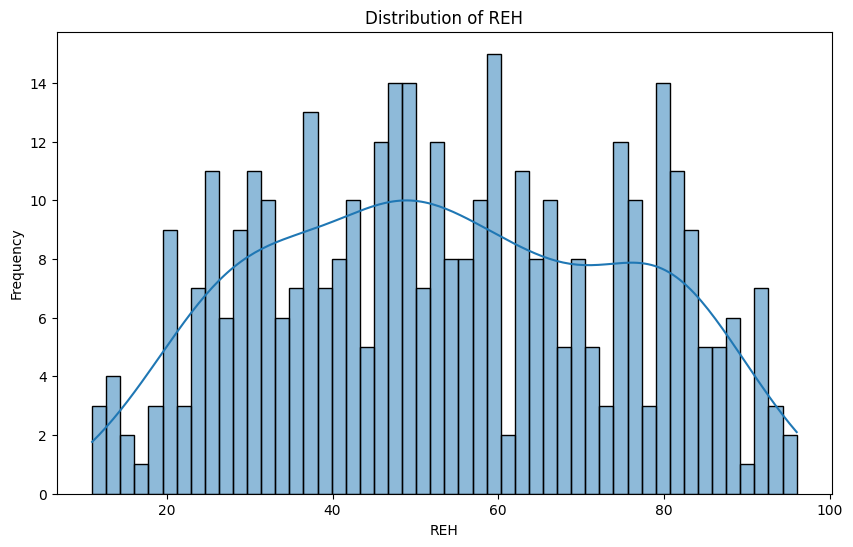

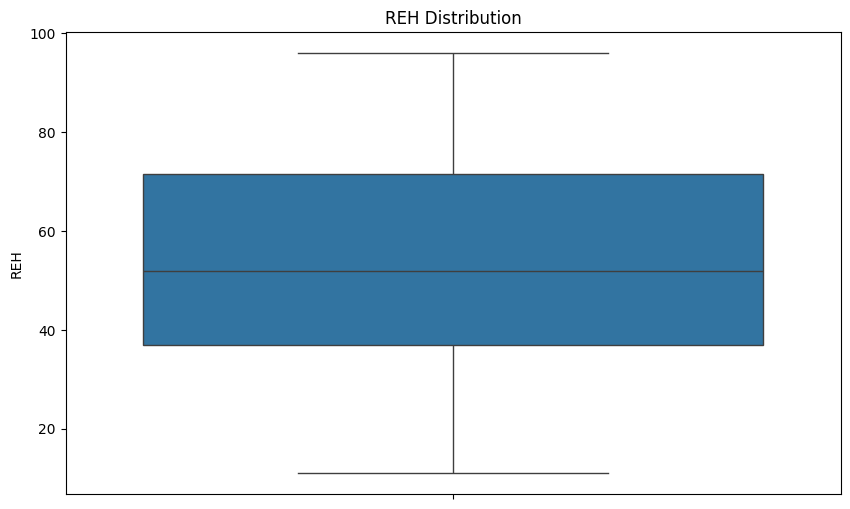

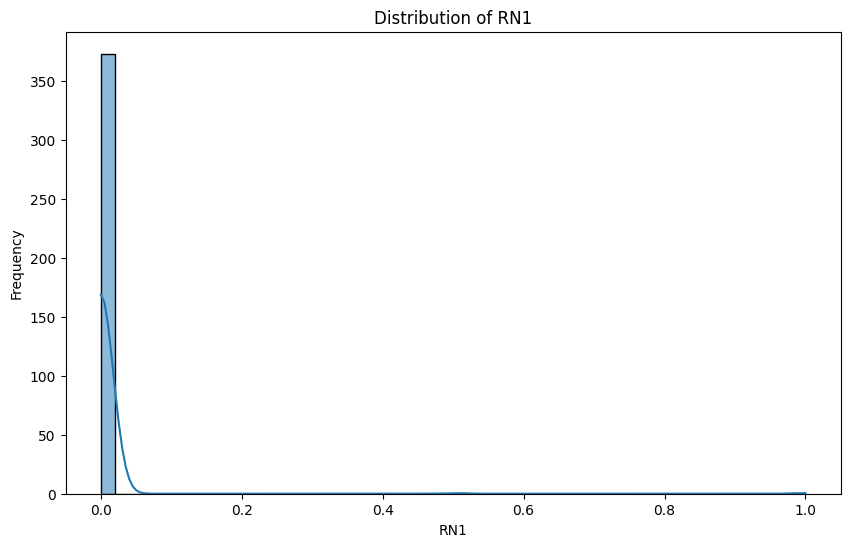

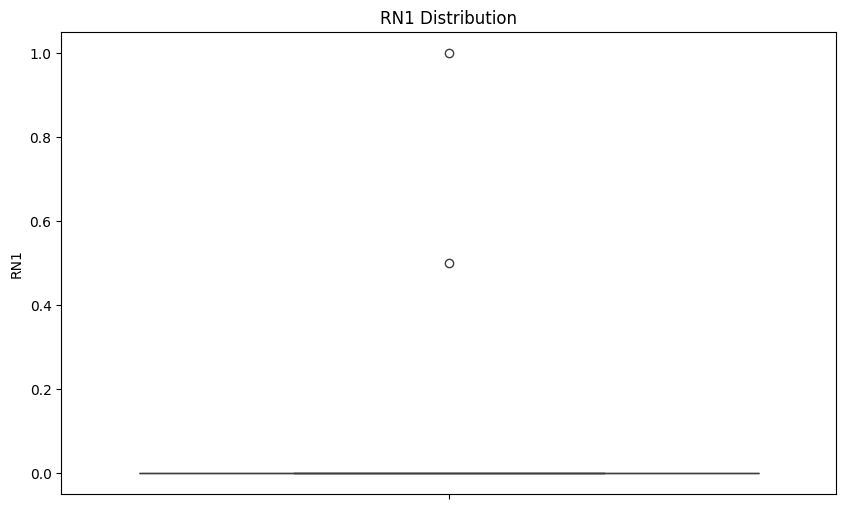

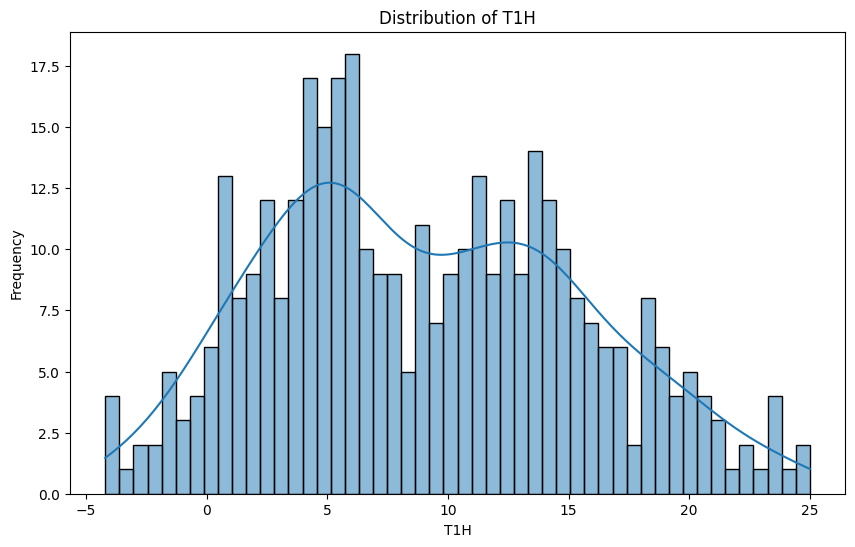

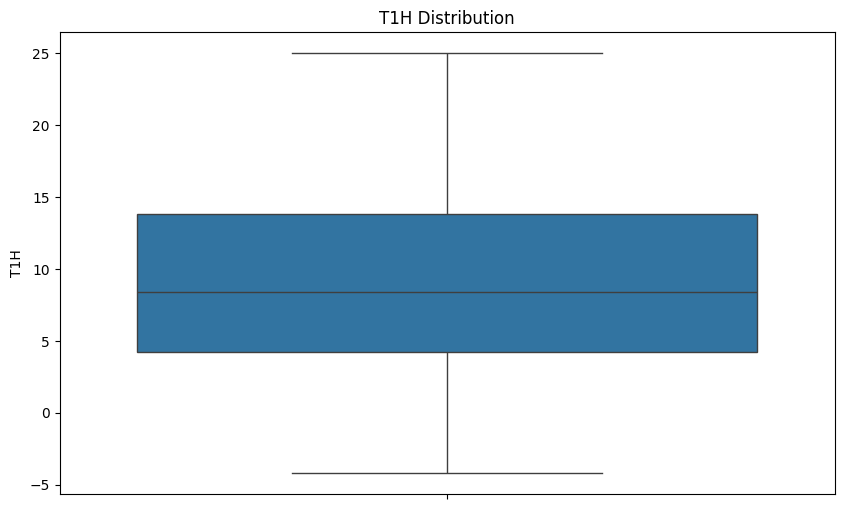

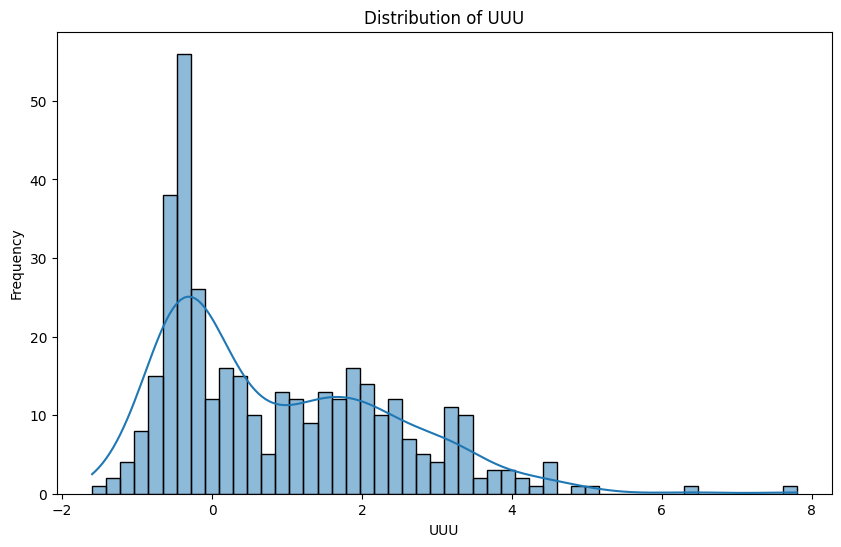

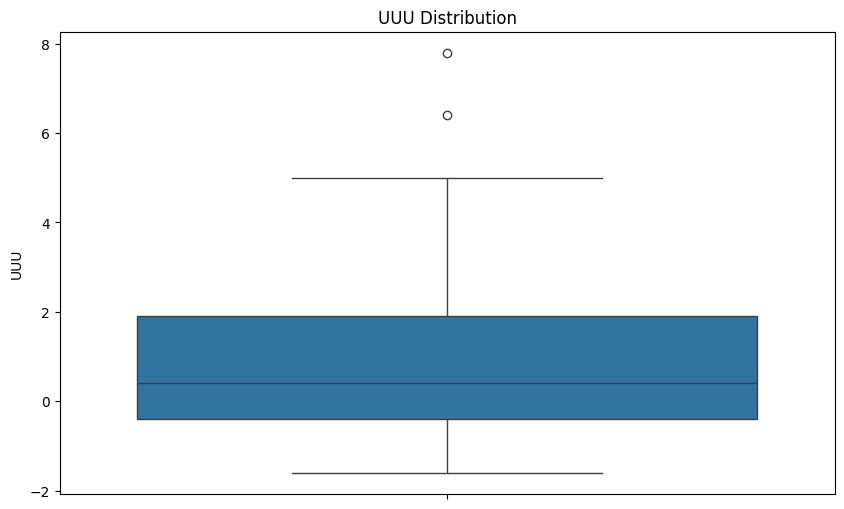

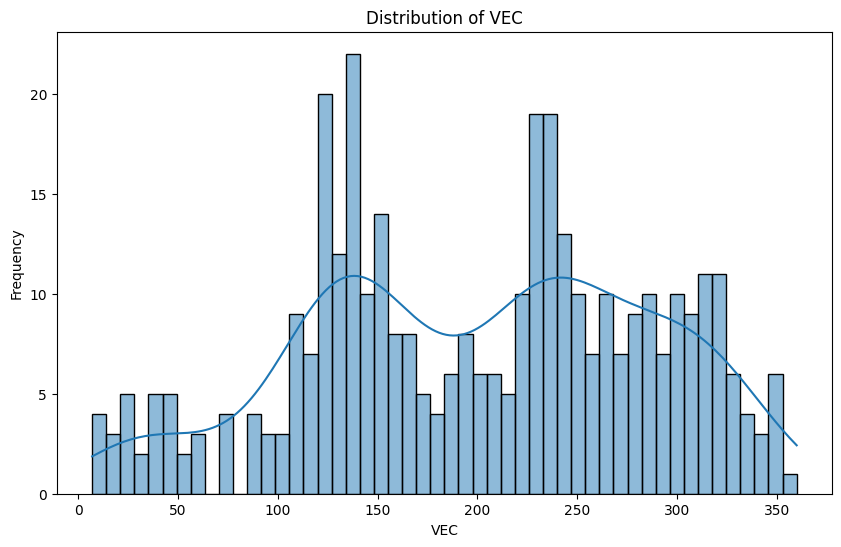

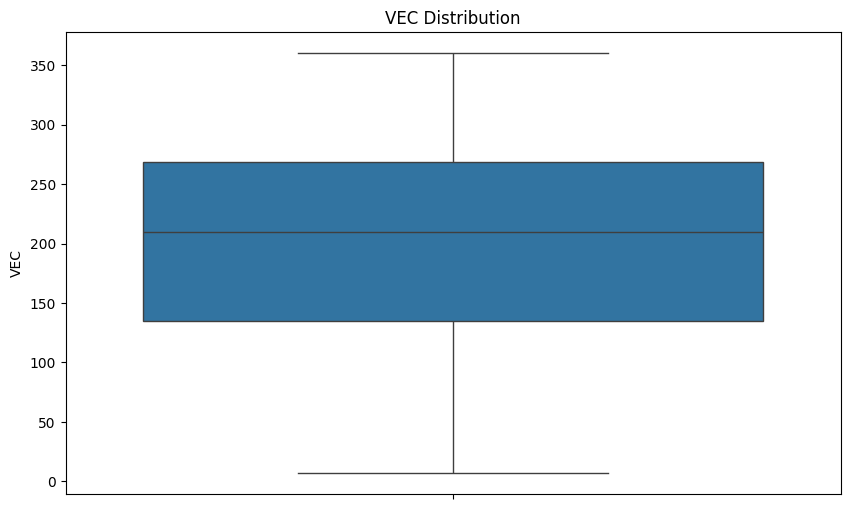

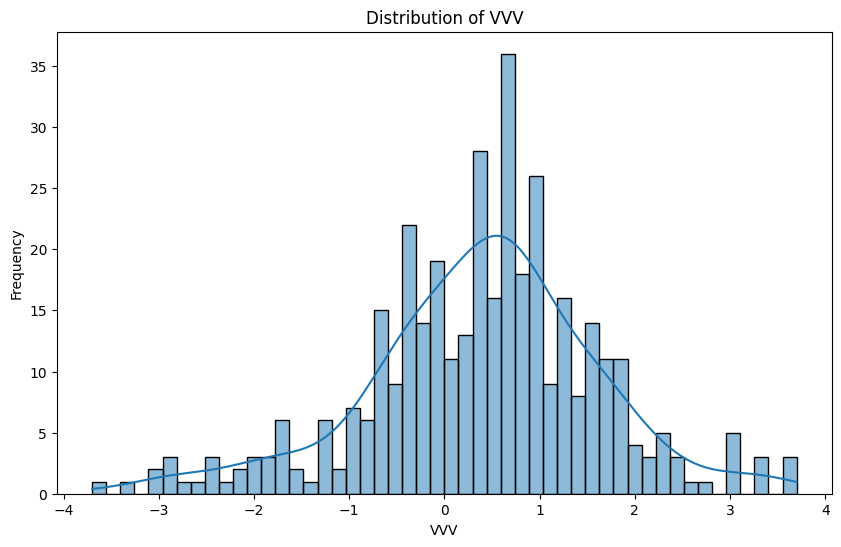

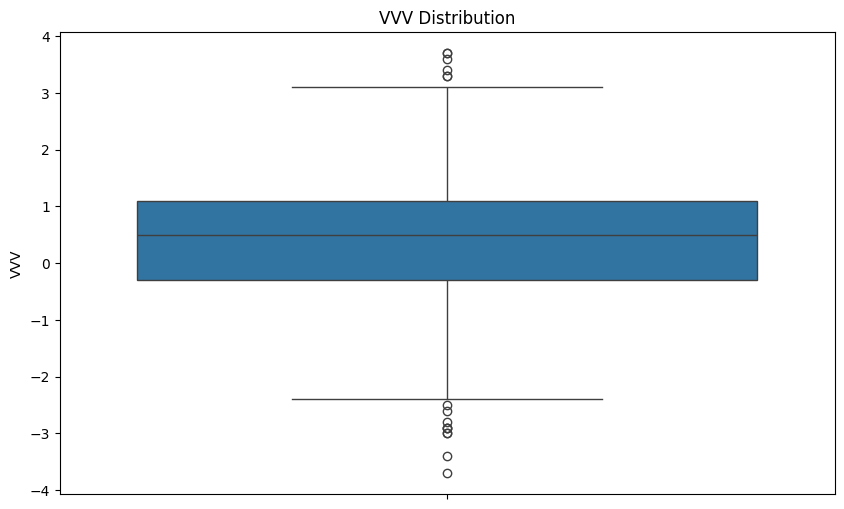

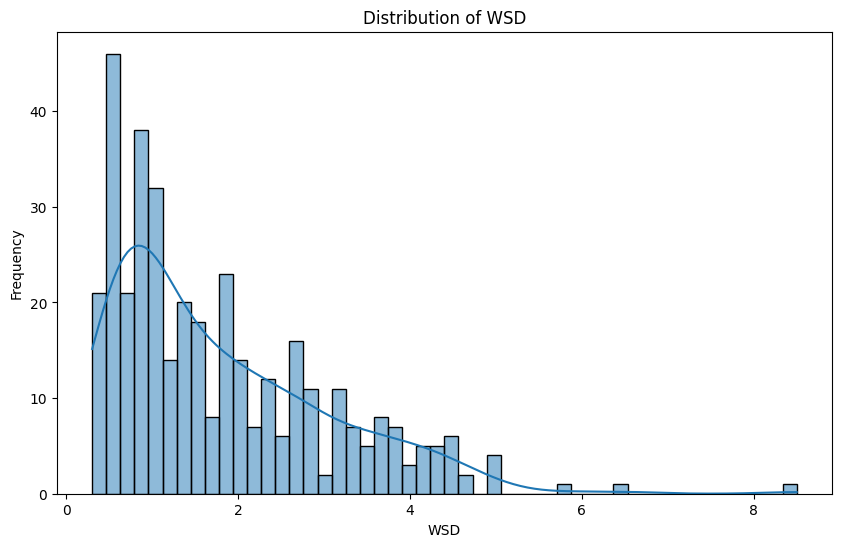

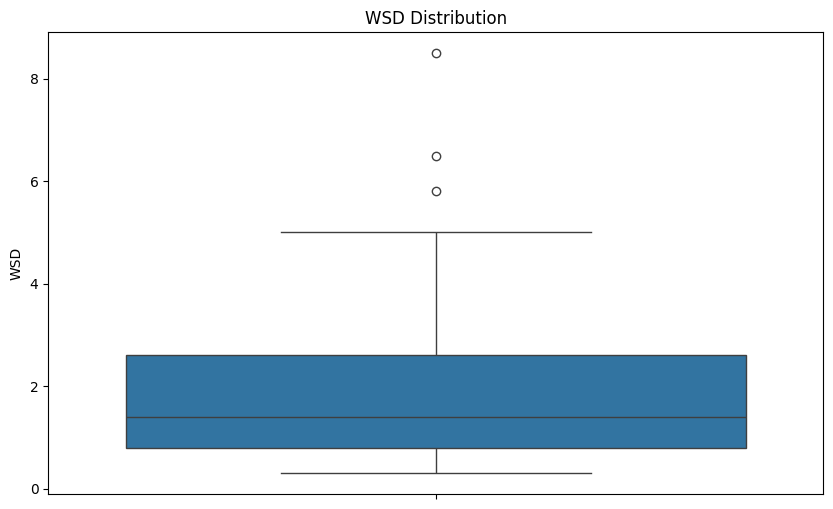

In [17]:
numeric_features= ['REH', 'RN1', 'T1H', 'UUU', 'VEC', 'VVV', 'WSD',]
data_seoul_merged
for feature in numeric_features:
    plt.figure(figsize=(10,6))
    sns.histplot(data_seoul_merged[feature], bins=50, kde=True)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.show()

    plt.figure(figsize=(10, 6))
    sns.boxplot(y=feature, data=data_seoul_merged)
    plt.title(f'{feature} Distribution')
    plt.xticks(rotation=45)
    plt.show()


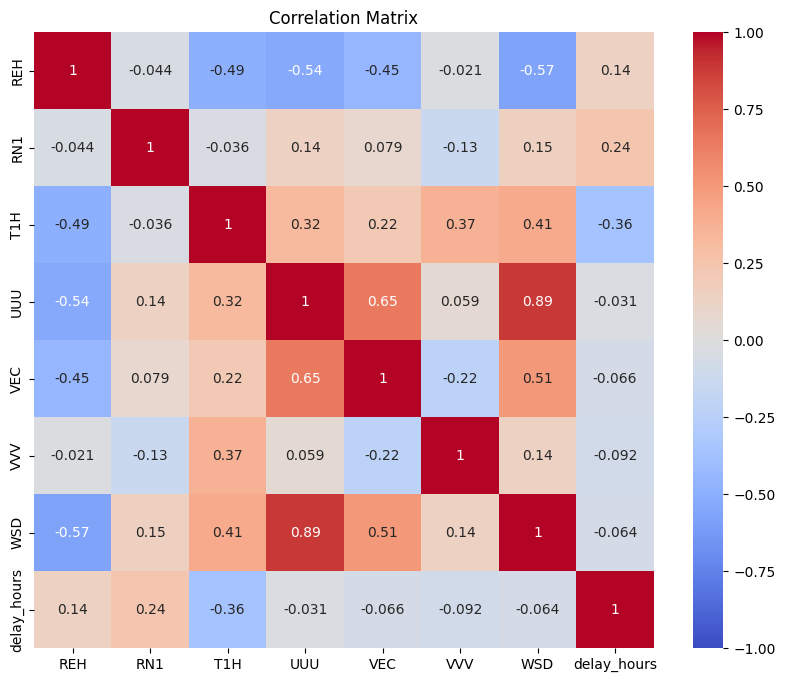

2025-04-08 13:54:23,035 - INFO - delay_hours와 피처 간 상관계수:
2025-04-08 13:54:23,036 - INFO - delay_hours    1.000000
RN1            0.240560
REH            0.139705
UUU           -0.030941
WSD           -0.063888
VEC           -0.066353
VVV           -0.091645
T1H           -0.362592
Name: delay_hours, dtype: float64


In [18]:
plt.figure(figsize=(10, 8))
correlation_matrix = data_seoul_merged[numeric_features + ['delay_hours']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()

# delay_hours와 피처 간 상관계수
logger.info("delay_hours와 피처 간 상관계수:")
logger.info(correlation_matrix['delay_hours'].sort_values(ascending=False))

In [19]:
# time series stationarity check
# autocorrelation check
# partial autocorrelation check 

In [25]:
result = adfuller(data_seoul_merged['delay_hours'])
logger.info(f"ADF Statistic: {result[0]}")
logger.info(f"p-value: {result[1]}")
logger.info(f"Critical Values: {result[4]}")
if result[1] < 0.05:
    logger.info("delay_hours is stationary (p-value < 0.05)")
else:
    logger.info("delay_hours is non-stationary (p-value >= 0.05)")

2025-04-08 13:57:02,239 - INFO - ADF Statistic: -5.0915754854458255
2025-04-08 13:57:02,239 - INFO - p-value: 1.4576246991290727e-05
2025-04-08 13:57:02,240 - INFO - Critical Values: {'1%': np.float64(-3.4482453822848496), '5%': np.float64(-2.8694261442901396), '10%': np.float64(-2.5709711770439507)}
2025-04-08 13:57:02,240 - INFO - delay_hours is stationary (p-value < 0.05)


<Axes: xlabel='timestamp'>

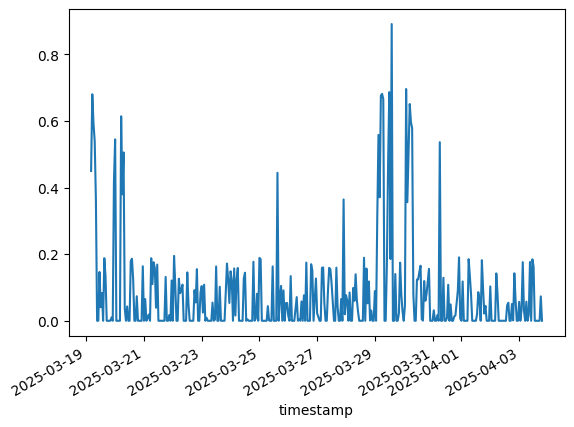

In [28]:
data_seoul_merged['delay_hours'].plot()

<Axes: xlabel='timestamp'>

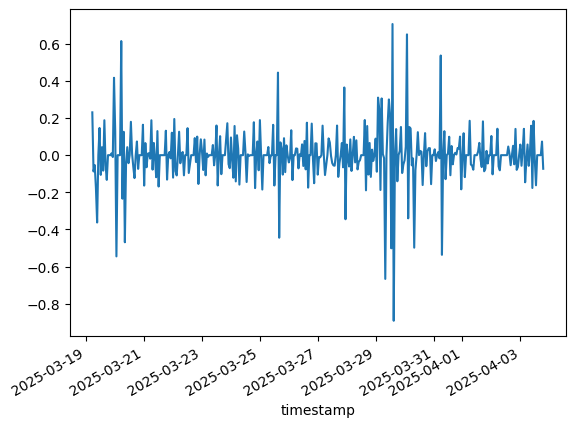

In [38]:
data_seoul_merged['delay_hours'].diff(1).plot()

In [34]:
np.log(data_seoul_merged['delay_hours'])


/Users/sunsekwon/.pyenv/versions/3.11.10/envs/venv-building-ml-pipeline/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


timestamp
2025-03-19 04:00:00   -0.798917
2025-03-19 05:00:00   -0.385242
2025-03-19 06:00:00   -0.522902
2025-03-19 07:00:00   -0.617180
2025-03-19 08:00:00   -1.014986
                         ...   
2025-04-03 15:00:00        -inf
2025-04-03 16:00:00        -inf
2025-04-03 17:00:00        -inf
2025-04-03 18:00:00   -2.614523
2025-04-03 19:00:00        -inf
Name: delay_hours, Length: 375, dtype: float64

<Axes: xlabel='timestamp'>

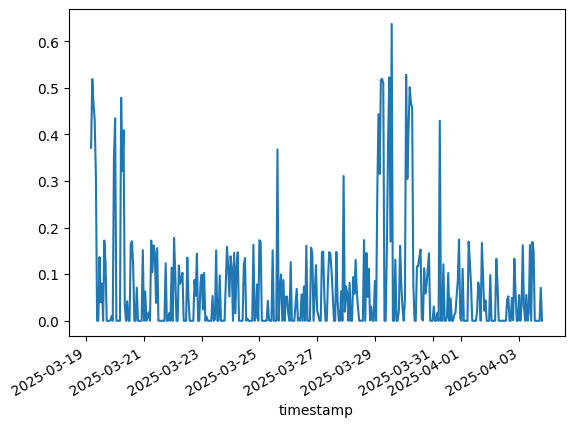

In [36]:
np.log1p(data_seoul_merged['delay_hours']).plot()

<Axes: xlabel='timestamp'>

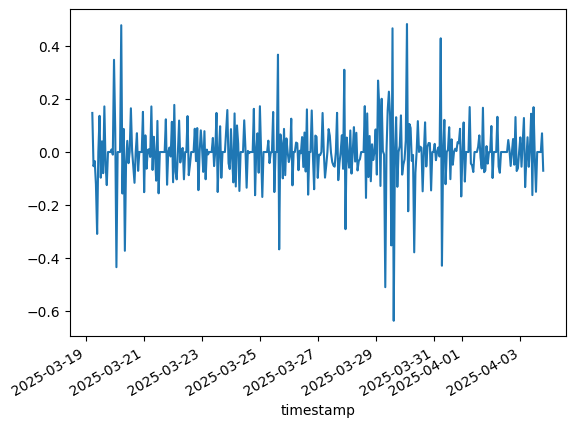

In [40]:
np.log1p(data_seoul_merged['delay_hours']).diff(1).plot()